# **Plotting Script: ENSO Transition Probability Experiment Split by Eruption Location**

Output:

1) "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_location.png"

Saved: /home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_location.png


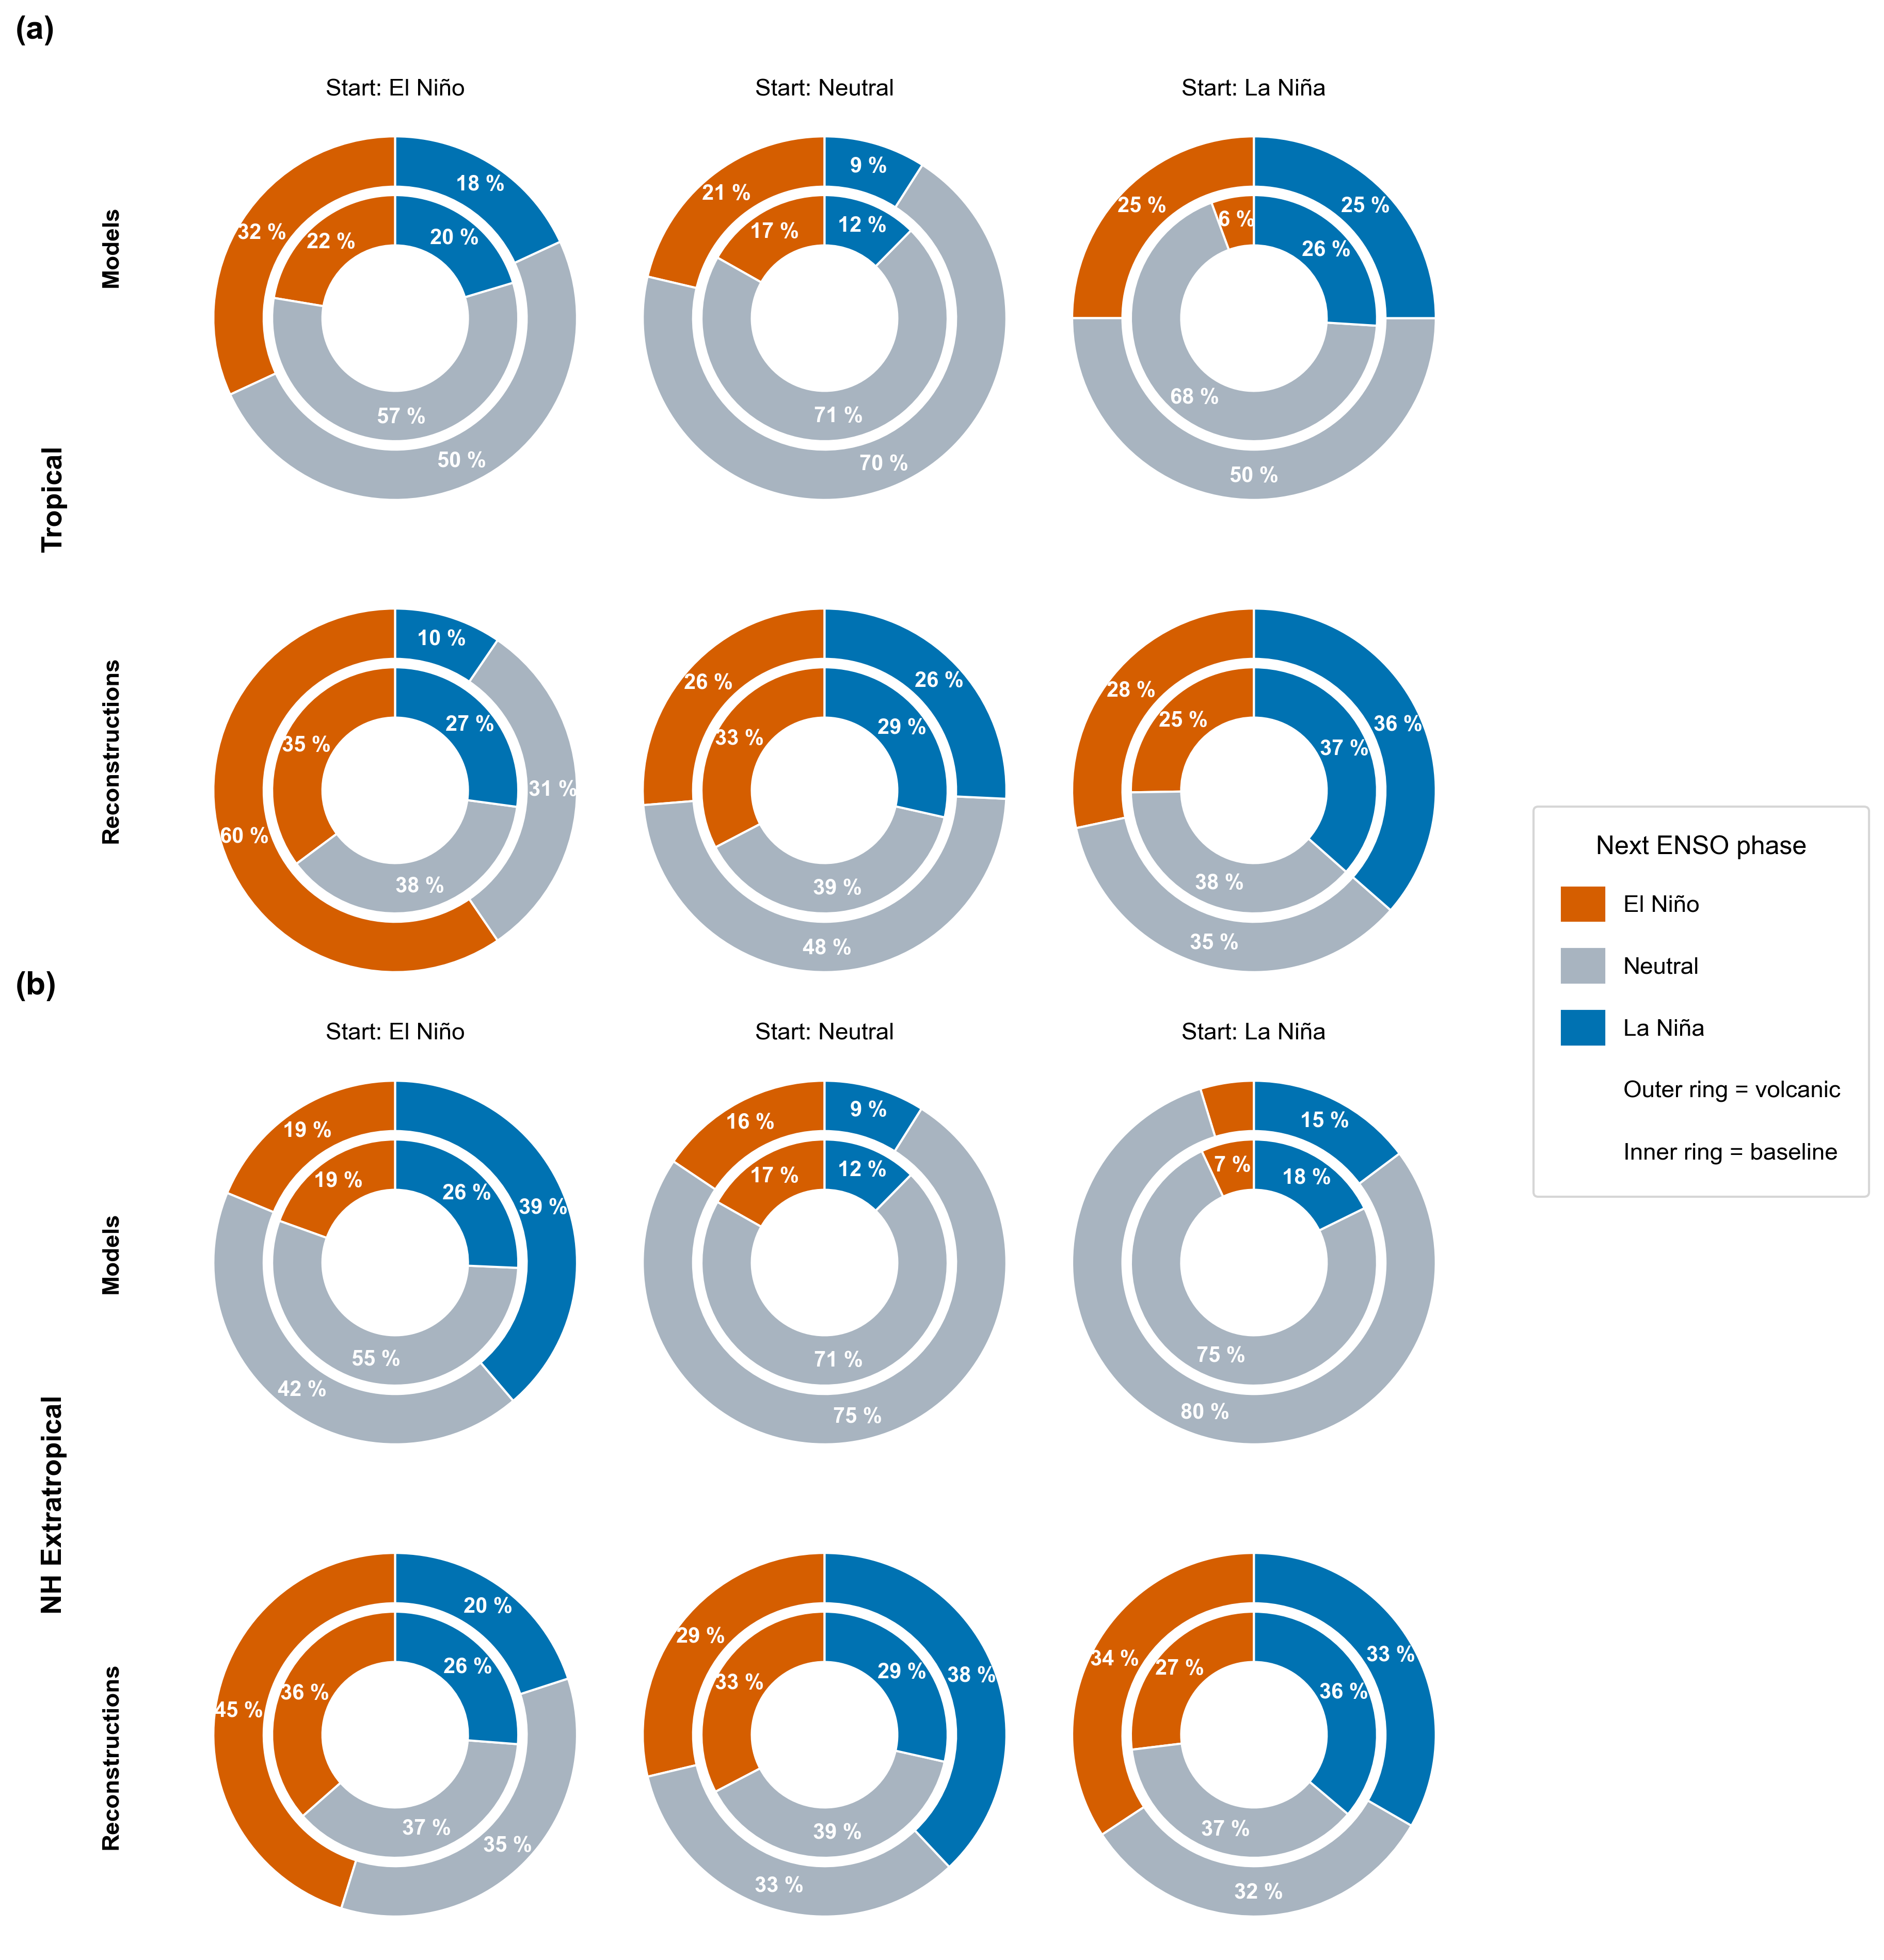

In [2]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D


# FONT
mpl.rcParams["font.family"]     = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]


# INPUT / OUTPUT
TABLE_DIR = "/home/563/ft3359/FT-Honours/Honours_Paper/Transition_Prob/Location_Analysis"
MODEL_CSV = os.path.join(TABLE_DIR, "TransProb_Models_Location.csv")
RECON_CSV = os.path.join(TABLE_DIR, "TransProb_Recons_Location.csv")
OUT_PNG   = "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/TransProb_location.png"


# SETTINGS
PHASES = ["El Niño", "Neutral", "La Niña"]
LOCATION_ORDER = ["Tropical", "NH Extratropical"]
PANEL_LABELS = string.ascii_lowercase

# Colour Set
PHASE_COLORS = {
    "El Niño": "#D55E00",
    "Neutral": "#A8B4C0",
    "La Niña": "#0072B2",
}

ANNOTATE_MIN_FRAC = 0.05

# Donut geometry
OUTER_RADIUS  = 1.30
INNER_RADIUS  = 0.88
RING_WIDTH    = 0.36
ERUPT_LABEL_R = 1.13
BASE_LABEL_R  = 0.71

# Font sizes
PCT_FONTSIZE          = 10
TITLE_FONTSIZE        = 11
ROW_LABEL_FONTSIZE    = 11
LOCATION_LABEL_FONTSIZE = 13
LEGEND_FONTSIZE       = 11
LEGEND_TITLE_FONTSIZE = 12
PANEL_LABEL_FONTSIZE  = 15

# HELPERS

def sanitize_prob_vector(p):
    p = np.asarray(p, dtype=float).copy()
    p[~np.isfinite(p)] = 0.0
    p[p < 0]           = 0.0
    s = p.sum()
    if s > 0:
        p /= s
    else:
        p[:] = 0.0
    return p


def read_wlp_csv_by_location(csv_path, location):
    df = pd.read_csv(csv_path)
    needed = {
        "location", "start_phase",
        "baseline_EN", "baseline_N", "baseline_LN",
        "eruption_EN", "eruption_N", "eruption_LN",
    }
    missing = sorted(needed - set(df.columns))
    if missing:
        raise KeyError(f"CSV missing columns {missing}: {csv_path}")

    df_loc = df[df["location"] == location]

    probs_base  = {}
    probs_erupt = {}

    for sp in PHASES:
        row = df_loc[df_loc["start_phase"] == sp]
        if row.empty:
            probs_base[sp]  = np.zeros(3, dtype=float)
            probs_erupt[sp] = np.zeros(3, dtype=float)
            continue
        r = row.iloc[0]
        probs_base[sp]  = sanitize_prob_vector(
            [r["baseline_EN"], r["baseline_N"], r["baseline_LN"]]
        )
        probs_erupt[sp] = sanitize_prob_vector(
            [r["eruption_EN"], r["eruption_N"], r["eruption_LN"]]
        )

    return probs_base, probs_erupt


def donut_on_ax(ax, pB, pE, title):
    colors = [PHASE_COLORS["El Niño"], PHASE_COLORS["Neutral"], PHASE_COLORS["La Niña"]]

    if pB.sum() <= 0 and pE.sum() <= 0:
        ax.text(0, 0, "No transitions", ha="center", va="center", fontsize=PCT_FONTSIZE)
        ax.set_title(title, fontsize=TITLE_FONTSIZE)
        ax.set_aspect("equal")
        ax.axis("off")
        return

    # Outer ring = eruption
    wedgesE = []
    if pE.sum() > 0:
        wedgesE, _ = ax.pie(
            pE,
            radius=OUTER_RADIUS,
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=RING_WIDTH, edgecolor="white"),
        )

    # Inner ring = baseline
    wedgesB = []
    if pB.sum() > 0:
        wedgesB, _ = ax.pie(
            pB,
            radius=INNER_RADIUS,
            colors=colors,
            startangle=90,
            wedgeprops=dict(width=RING_WIDTH, edgecolor="white"),
        )

    # Percentage labels
    for i in range(3):
        if i < len(wedgesE) and pE[i] >= ANNOTATE_MIN_FRAC:
            ang = (wedgesE[i].theta1 + wedgesE[i].theta2) / 2
            ax.text(
                ERUPT_LABEL_R * np.cos(np.deg2rad(ang)),
                ERUPT_LABEL_R * np.sin(np.deg2rad(ang)),
                f"{100*pE[i]:.0f} %",
                ha="center", va="center",
                fontsize=PCT_FONTSIZE, color="white", weight="bold",
            )

        if i < len(wedgesB) and pB[i] >= ANNOTATE_MIN_FRAC:
            ang = (wedgesB[i].theta1 + wedgesB[i].theta2) / 2
            ax.text(
                BASE_LABEL_R * np.cos(np.deg2rad(ang)),
                BASE_LABEL_R * np.sin(np.deg2rad(ang)),
                f"{100*pB[i]:.0f} %",
                ha="center", va="center",
                fontsize=PCT_FONTSIZE, color="white", weight="bold",
            )

    lim = OUTER_RADIUS + 0.20
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    ax.set_aspect("equal")
    ax.axis("off")

# LOAD DATA

for p in [MODEL_CSV, RECON_CSV]:
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing input CSV: {p}")

data_by_location = {}
for location in LOCATION_ORDER:
    model_base, model_erupt = read_wlp_csv_by_location(MODEL_CSV, location)
    recon_base, recon_erupt = read_wlp_csv_by_location(RECON_CSV, location)
    data_by_location[location] = dict(
        model_base=model_base, model_erupt=model_erupt,
        recon_base=recon_base, recon_erupt=recon_erupt,
    )


# PLOT — LOCATION blocks stacked vertically, each block = 2 rows (Models, Recons) x 3 columns (phases)

n_rows = len(LOCATION_ORDER) * 2
fig, axes = plt.subplots(n_rows, 3, figsize=(11, 6.5 * len(LOCATION_ORDER)), dpi=300)
if n_rows == 1:
    axes = axes.reshape(1, -1)

row_label_ys = []

for li, location in enumerate(LOCATION_ORDER):
    d = data_by_location[location]
    row_models = li * 2
    row_recons = li * 2 + 1

    for j, sp in enumerate(PHASES):
        donut_on_ax(
            axes[row_models, j],
            d["model_base"].get(sp,  np.zeros(3)),
            d["model_erupt"].get(sp, np.zeros(3)),
            title=f"Start: {sp}",
        )
    for j, sp in enumerate(PHASES):
        donut_on_ax(
            axes[row_recons, j],
            d["recon_base"].get(sp,  np.zeros(3)),
            d["recon_erupt"].get(sp, np.zeros(3)),
            title="",
        )

    row_label_ys.append((row_models, row_recons, location))


# Row labels (Models / Reconstructions) + Location block labels

plt.tight_layout(rect=[0.08, 0.02, 0.88, 0.97])

n_total_rows = n_rows
for li, (row_models, row_recons, location) in enumerate(row_label_ys):
    y_models = 1.0 - (row_models + 0.5) / n_total_rows
    y_recons = 1.0 - (row_recons + 0.5) / n_total_rows
    y_block  = 1.0 - (row_models + 1.0) / n_total_rows
    y_top    = 1.0 - row_models / n_total_rows

    fig.text(0.055, y_models, "Models", rotation=90, va="center", ha="left",
              fontsize=ROW_LABEL_FONTSIZE, fontweight="bold")
    fig.text(0.055, y_recons, "Reconstructions", rotation=90, va="center", ha="left",
              fontsize=ROW_LABEL_FONTSIZE, fontweight="bold")

    fig.text(0.02, y_block, location, rotation=90, va="center", ha="left",
              fontsize=LOCATION_LABEL_FONTSIZE, fontweight="bold")

    fig.text(0.005, min(y_top + 0.015, 0.99), f"({PANEL_LABELS[li]})",
              ha="left", va="top", fontsize=PANEL_LABEL_FONTSIZE, fontweight="bold")


# Legend
color_handles = [Rectangle((0, 0), 1, 1, color=PHASE_COLORS[ph])
                 for ph in ["El Niño", "Neutral", "La Niña"]]
color_labels  = ["El Niño", "Neutral", "La Niña"]

blank         = Line2D([], [], linestyle="none", marker="none")
ring_handles  = [blank, blank]
ring_labels   = ["Outer ring = volcanic", "Inner ring = baseline"]

all_handles = color_handles + ring_handles
all_labels  = color_labels  + ring_labels

leg = fig.legend(
    all_handles,
    all_labels,
    title="Next ENSO phase",
    loc="center right",
    bbox_to_anchor=(1.10, 0.5),
    fontsize=LEGEND_FONTSIZE,
    title_fontsize=LEGEND_TITLE_FONTSIZE,
    labelspacing=1.2,
    handlelength=1.8,
    handleheight=1.8,
    handletextpad=0.8,
    borderpad=1.2,
    frameon=True,
)

for handle, text in zip(leg.legend_handles, leg.get_texts()):
    if text.get_text() in ring_labels:
        handle.set_visible(False)

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print("Saved:", OUT_PNG)

plt.show()